# Mediciones



In [1]:
import random
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

random.seed(42)
np.random.seed(42)

In [2]:
def tiempo_minimo(rivales):
    rivales_ordenados = sorted(rivales, key=lambda x: x[1], reverse=True)
    tiempo_scaloni = 0
    tiempo_total = 0 
    for s_i, a_i in rivales_ordenados:
        tiempo_scaloni += s_i
        final = tiempo_scaloni + a_i
        tiempo_total = max(tiempo_total, final)
    return rivales_ordenados, tiempo_total

## Generación de datos

In [3]:
def generar_rivales_aleatorios(n):
    return [(random.randint(1, 1000), random.randint(1, 1000)) for _ in range(n)]
def generar_rivales_creciente(n):
    return [(random.randint(1, 1000), i + 1) for i in range(n)]
def generar_rivales_decreciente(n):
    return [(random.randint(1, 1000), n - i) for i in range(n)]

Se definen tres funciones para generar conjuntos de rivales con distintas distribuciones de a_i: aleatoria, creciente y decreciente. En todos los casos s_i es aleatorio en [1, 1000].

## Reducción de dispersión en las mediciones

In [4]:
def medir_tiempo(rivales, repeticiones=30):
    tiempos = []
    for _ in range(repeticiones):
        inicio = time.perf_counter()
        tiempo_minimo(rivales)
        tiempos.append(time.perf_counter() - inicio)
 
    tiempos.sort()
    n = len(tiempos)
    tercio = n // 3
    tercio_medio = tiempos[tercio: 2 * tercio]
    return sum(tercio_medio) / len(tercio_medio)

Dada la dispersión natural en los tiempos medidos, cada conjunto se ejecuta 30 veces. Los tiempos se ordenan y se descartan el tercio inferior y el tercio superior, quedándose únicamente con el tercio central. Se devuelve el promedio del tercio central.

## Ajuste de complejidad

Se generan 25 tamaños de entrada entre 1.000 y 1.000.000 rivales. Para cada tamaño se genera un conjunto aleatorio y se mide su tiempo de ejecución con la función descripta anteriormente.

In [5]:
    tamanios = np.linspace(1000, 1000000, 25).astype(int)
    tiempos = []
 
    print("Midiendo tiempos...")
    for n in tamanios:
        rivales = generar_rivales_aleatorios(n)
        t = medir_tiempo(rivales)
        tiempos.append(t)

Midiendo tiempos...


In [6]:
    tamanios_f = tamanios.astype(float)
    tiempos_f  = np.array(tiempos)

    modelo_n      = lambda x, c1, c2: c1 * x + c2
    modelo_nlogn  = lambda x, c1, c2: c1 * x * np.log(x) + c2
    modelo_n2     = lambda x, c1, c2: c1 * x**2 + c2
 
    params_n,     _ = curve_fit(modelo_n,     tamanios_f, tiempos_f)
    params_nlogn, _ = curve_fit(modelo_nlogn, tamanios_f, tiempos_f)
    params_n2,    _ = curve_fit(modelo_n2,    tamanios_f, tiempos_f)

In [7]:
    def r2(y_real, y_pred):
        ss_res = np.sum((y_real - y_pred) ** 2)
        ss_tot = np.sum((y_real - np.mean(y_real)) ** 2)
        return 1 - ss_res / ss_tot
        
    r2_n     = r2(tiempos_f, modelo_n(tamanios_f,     *params_n))
    r2_nlogn = r2(tiempos_f, modelo_nlogn(tamanios_f, *params_nlogn))
    r2_n2    = r2(tiempos_f, modelo_n2(tamanios_f,    *params_n2))


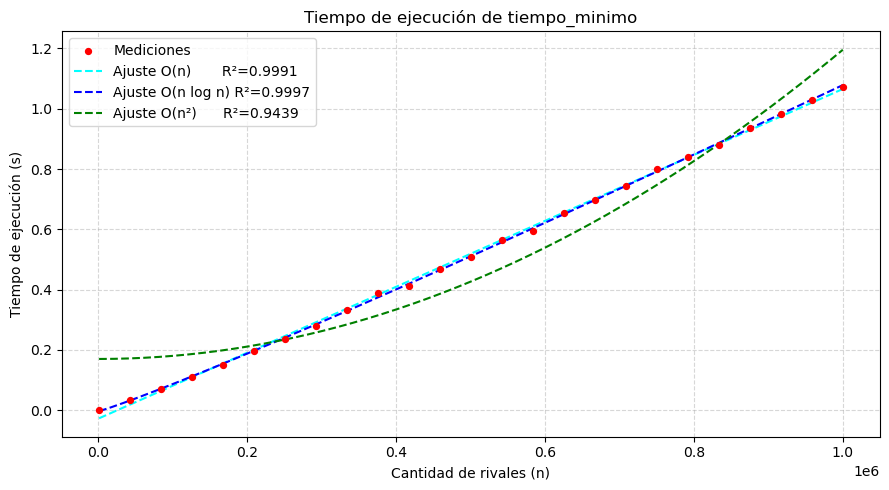

In [8]:
    x_plot = np.linspace(tamanios[0], tamanios[-1], 300)
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.scatter(tamanios_f, tiempos_f, color='red', s=18, zorder=5, label='Mediciones')
    ax.plot(x_plot, modelo_n(x_plot,     *params_n),     color='cyan',  linestyle='--', label=f'Ajuste O(n)       R²={r2_n:.4f}')
    ax.plot(x_plot, modelo_nlogn(x_plot, *params_nlogn), color='blue',  linestyle='--', label=f'Ajuste O(n log n) R²={r2_nlogn:.4f}')
    ax.plot(x_plot, modelo_n2(x_plot,    *params_n2),    color='green', linestyle='--', label=f'Ajuste O(n²)      R²={r2_n2:.4f}')
    ax.set_title('Tiempo de ejecución de tiempo_minimo')
    ax.set_xlabel('Cantidad de rivales (n)')
    ax.set_ylabel('Tiempo de ejecución (s)')
    ax.legend()
    ax.grid(linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig('ajuste_complejidad.png', dpi=300)
    plt.show()

## Errores residuales 

Para cada tamaño de entrada se calcula la diferencia entre el tiempo medido y el tiempo predicho por cada modelo. Estos errores residuales se grafican en función de n.

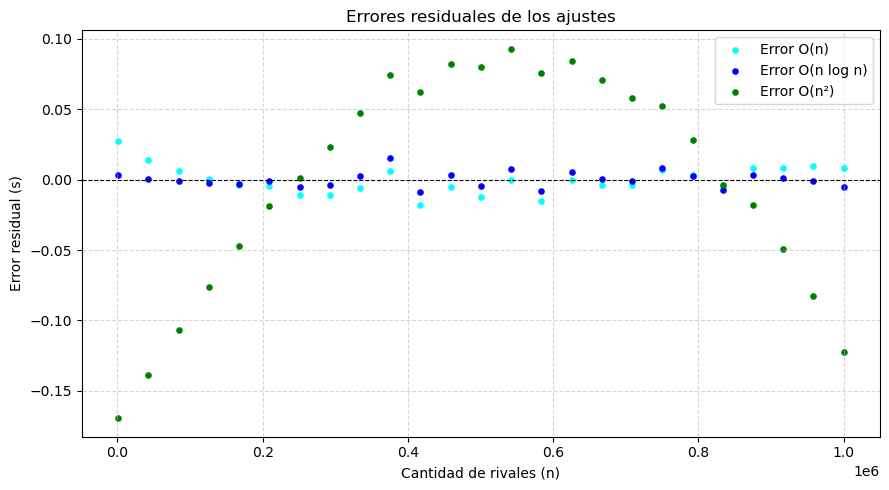

In [9]:
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.scatter(tamanios_f, tiempos_f - modelo_n(tamanios_f,     *params_n),     color='cyan',  s=14, label='Error O(n)')
    ax.scatter(tamanios_f, tiempos_f - modelo_nlogn(tamanios_f, *params_nlogn), color='blue',  s=14, label='Error O(n log n)')
    ax.scatter(tamanios_f, tiempos_f - modelo_n2(tamanios_f,    *params_n2),    color='green', s=14, label='Error O(n²)')
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_title('Errores residuales de los ajustes')
    ax.set_xlabel('Cantidad de rivales (n)')
    ax.set_ylabel('Error residual (s)')
    ax.legend()
    ax.grid(linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig('errores_residuales.png', dpi=300)
    plt.show()

## Comparación R² 

Se calcula el coeficiente R² para cada modelo. Este coeficiente se define como 1 menos el cociente entre la suma de cuadrados de los residuos y la suma total de cuadrados. Un R²=1 indica ajuste perfecto

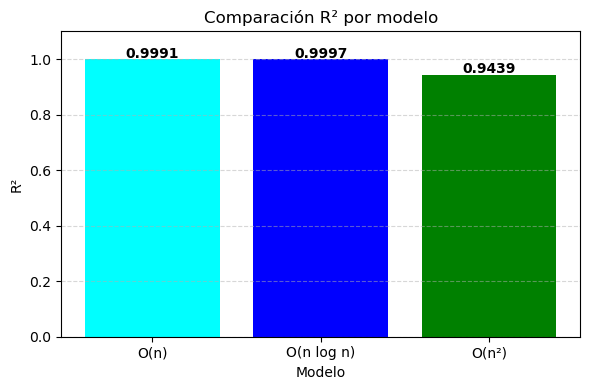

In [10]:
    fig, ax = plt.subplots(figsize=(6, 4))
    modelos  = ['O(n)', 'O(n log n)', 'O(n²)']
    colores  = ['cyan', 'blue', 'green']
    valores  = [r2_n, r2_nlogn, r2_n2]
    bars = ax.bar(modelos, valores, color=colores)
    for bar, v in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
                f'{v:.4f}', ha='center', fontweight='bold', fontsize=10)
    ax.set_ylim(0, 1.1)
    ax.set_xlabel('Modelo')
    ax.set_ylabel('R²')
    ax.set_title('Comparación R² por modelo')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig('comparacion_r2.png', dpi=300)
    plt.show()

## Comparación por distribución de datos

Se generan tres conjuntos de 50.000 rivales con distintas distribuciones de a_i y se mide el tiempo de ejecución de cada uno. El objetivo es analizar si la distribución de los datos de entrada afecta el tiempo de ejecución en la práctica

In [11]:
    n = 50_000
 
    distribuciones = {
        'a_i decreciente\n(mejor caso greedy)': generar_rivales_decreciente(n),
        'a_i aleatorio':                         generar_rivales_aleatorios(n),
        'a_i creciente\n(peor caso greedy)':    generar_rivales_creciente(n),
    }

In [12]:
    etiquetas = []
    tiempos   = []
 
    for nombre, rivales in distribuciones.items():
        t = medir_tiempo(rivales)
        etiquetas.append(nombre)
        tiempos.append(t)

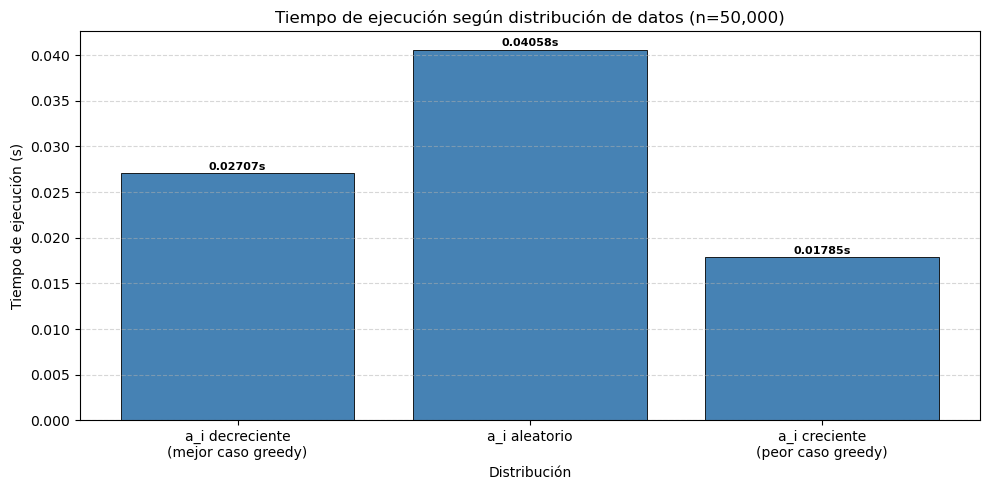

In [13]:
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(etiquetas, tiempos, color='steelblue', edgecolor='black', linewidth=0.6)
    for bar, v in zip(bars, tiempos):
        ax.text(bar.get_x() + bar.get_width() / 2, v + max(tiempos) * 0.01,
                f'{v:.5f}s', ha='center', fontsize=8, fontweight='bold')
    ax.set_title(f'Tiempo de ejecución según distribución de datos (n={n:,})')
    ax.set_xlabel('Distribución')
    ax.set_ylabel('Tiempo de ejecución (s)')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig('comparacion_distribucion.png', dpi=300)
    plt.show()